In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

# Data Preprocessing

In [2]:
df = pd.read_excel('data_ML2.xlsx')
df.head()

,C,H,N,O,MaxPartialCharge,MinPartialCharge,BCUT2D_LOGPLOW,BCUT2D_LOGPHI,BCUT2D_CHGHI,BCUT2D_MRLOW,...,NumRotatableBonds,BalabanJ,Kappa1,NumHAcceptors,Input Formation Enthalpy (kJ/mol),N(mol/g),M(g/mol),HOT(J/g),veloci(km/s),press(Gpa)
0,12,16,8,12,0.294019,-0.383868,-3.486647,3.184143,3.399440,-0.842051,...,12,1.665643,20.537557,14,2063.182511,0.03015,24.57,10305.98,8.92,34.36
1,10,13,7,10,0.293995,-0.384062,-3.534271,3.123573,3.427110,-0.820235,...,8,1.650393,16.564749,12,1801.040134,0.03003,24.85,10381.51,9.06,35.89
2,10,12,4,10,0.293995,-0.383940,-3.512661,3.129898,3.426237,-0.841134,...,6,1.626162,14.498584,11,1255.198155,0.02872,25.20,10031.99,8.83,34.10
3,10,12,8,6,0.183110,-0.382566,-3.542917,3.117207,3.419354,-0.792458,...,5,1.806522,14.068647,10,2059.781470,0.02939,22.00,10318.64,8.40,29.95
4,10,13,5,9,0.293995,-0.383701,-3.522992,3.123978,3.416772,-0.819032,...,6,1.626162,14.498584,11,1446.475544,0.02952,23.61,10109.62,8.66,32.35


In [3]:
df.columns

Index(['C', 'H', 'N', 'O', 'MaxPartialCharge', 'MinPartialCharge',
       'BCUT2D_LOGPLOW', 'BCUT2D_LOGPHI', 'BCUT2D_CHGHI', 'BCUT2D_MRLOW',
       'BCUT2D_MWHI', 'FpDensityMorgan1', 'FpDensityMorgan3', 'MolLogP', 'qed',
       'MinEStateIndex', 'TPSA', 'HallKierAlpha', 'NOCount', 'BertzCT',
       'MinAbsEStateIndex', 'NumHeteroatoms', 'Kappa3', 'NumRotatableBonds',
       'BalabanJ', 'Kappa1', 'NumHAcceptors',
       'Input Formation Enthalpy (kJ/mol)', 'N(mol/g)', 'M(g/mol)', 'HOT(J/g)',
       'veloci(km/s)', 'press(Gpa)'],
      dtype='object')

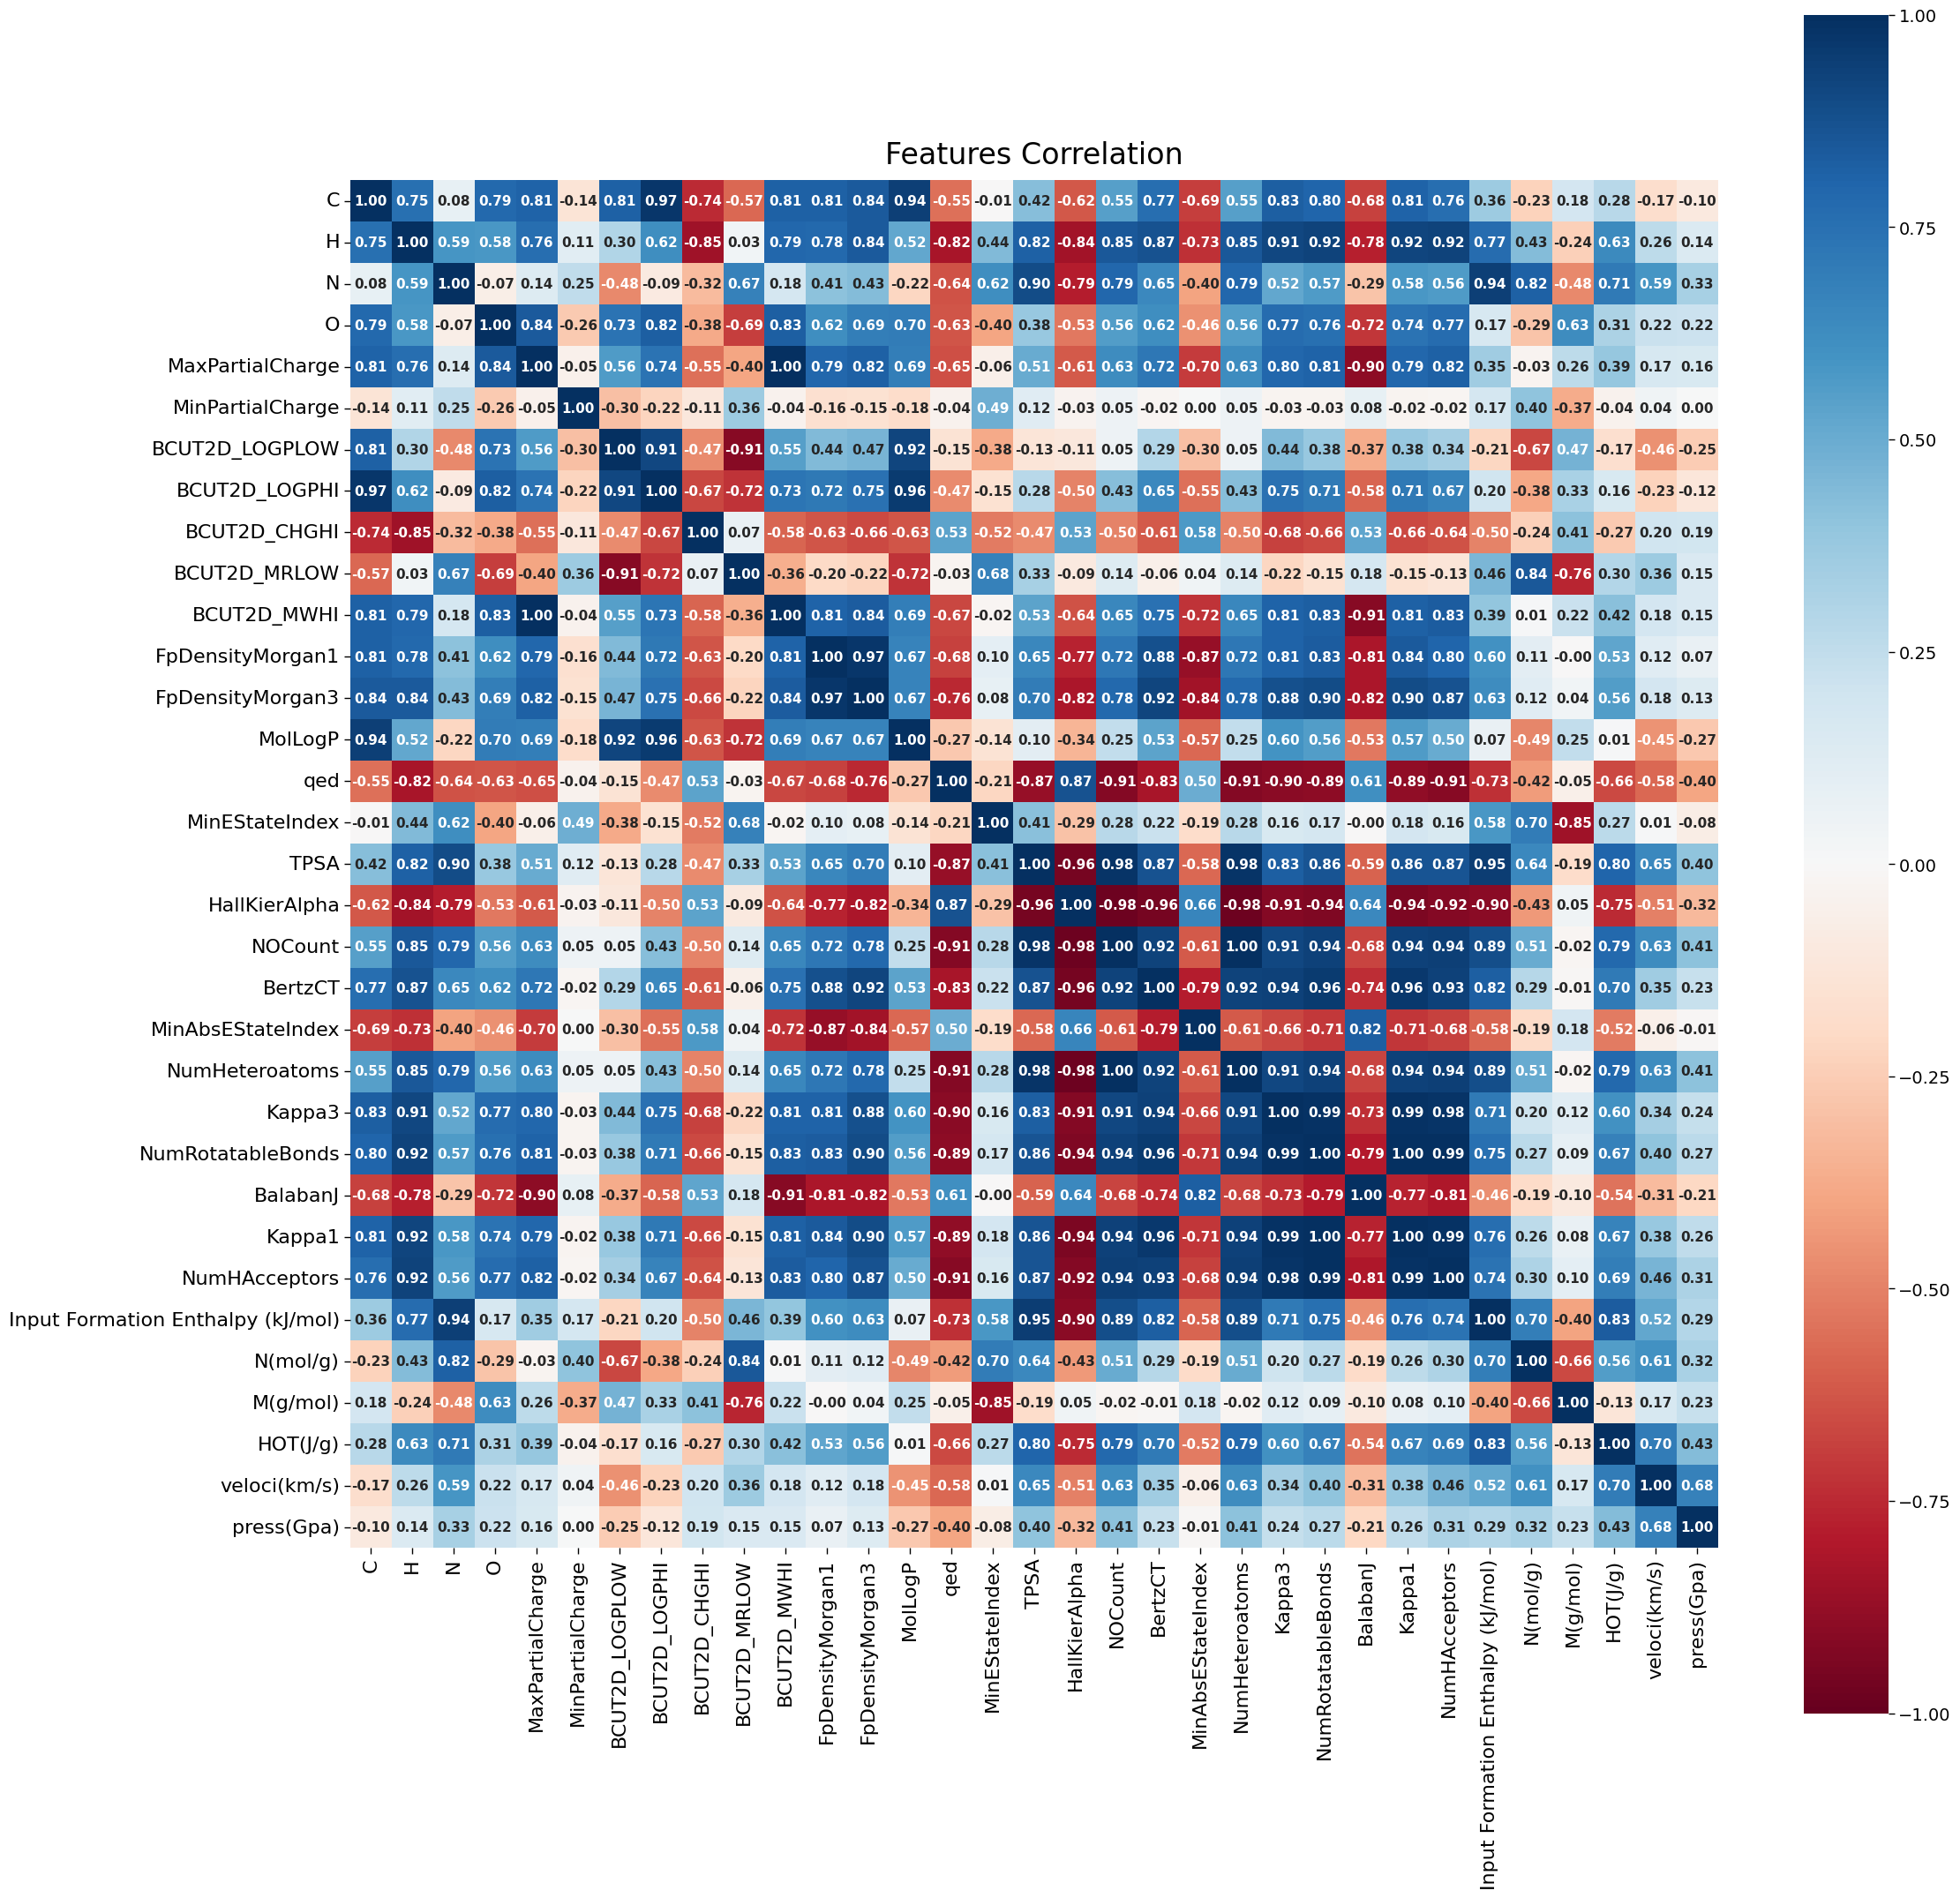

In [4]:
sns.set_context("paper", rc={"axes.labelsize":20})
fig, ax = plt.subplots(figsize=(25,25))  
heatmap = sns.heatmap(df.corr(), annot=True, annot_kws={'fontsize':11, 'fontweight':'bold'}, 
            cmap='RdBu', vmin=-1, vmax=1, square=True, fmt='0.2f', ax=ax)
heatmap.set_title('Features Correlation', fontdict={'fontsize':24}, pad=14)
heatmap.set_xticklabels(heatmap.get_xmajorticklabels(), fontsize = 16)
heatmap.set_yticklabels(heatmap.get_ymajorticklabels(), fontsize = 16)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

In [5]:
X = df.iloc[:,:27]
Y = df.iloc[:,27:]

In [6]:
X.head()

,C,H,N,O,MaxPartialCharge,MinPartialCharge,BCUT2D_LOGPLOW,BCUT2D_LOGPHI,BCUT2D_CHGHI,BCUT2D_MRLOW,...,HallKierAlpha,NOCount,BertzCT,MinAbsEStateIndex,NumHeteroatoms,Kappa3,NumRotatableBonds,BalabanJ,Kappa1,NumHAcceptors
0,12,16,8,12,0.294019,-0.383868,-3.486647,3.184143,3.399440,-0.842051,...,-3.36,20,1045.469395,0.427150,20,1.058323,12,1.665643,20.537557,14
1,10,13,7,10,0.293995,-0.384062,-3.534271,3.123573,3.427110,-0.820235,...,-2.60,17,863.556007,0.477749,17,0.715287,8,1.650393,16.564749,12
2,10,12,4,10,0.293995,-0.383940,-3.512661,3.129898,3.426237,-0.841134,...,-1.84,14,755.600538,0.517893,14,0.530079,6,1.626162,14.498584,11
3,10,12,8,6,0.183110,-0.382566,-3.542917,3.117207,3.419354,-0.792458,...,-2.31,14,862.776644,0.431226,14,0.480119,5,1.806522,14.068647,10
4,10,13,5,9,0.293995,-0.383701,-3.522992,3.123978,3.416772,-0.819032,...,-1.84,14,756.680854,0.392893,14,0.530079,6,1.626162,14.498584,11


In [7]:
Y.head()

,Input Formation Enthalpy (kJ/mol),N(mol/g),M(g/mol),HOT(J/g),veloci(km/s),press(Gpa)
0,2063.182511,0.03015,24.57,10305.98,8.92,34.36
1,1801.040134,0.03003,24.85,10381.51,9.06,35.89
2,1255.198155,0.02872,25.20,10031.99,8.83,34.10
3,2059.781470,0.02939,22.00,10318.64,8.40,29.95
4,1446.475544,0.02952,23.61,10109.62,8.66,32.35


In [8]:
X = X.values
Y = Y.values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((89, 27), (23, 27), (89, 6), (23, 6))

# Model training Linear Regression


In [10]:
pca = PCA(n_components=10)
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)
X_train_reduced.shape, X_test_reduced.shape

((89, 10), (23, 10))

In [11]:
# Create base GBR model
base_gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Wrap with MultiOutputRegressor
gbr = MultiOutputRegressor(base_gbr)

# Train the model
gbr.fit(X_train_reduced, y_train)

MultiOutputRegressor(estimator=GradientBoostingRegressor(random_state=42))

# Model testing

In [13]:
y_pred = gbr.predict(X_test_reduced)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)

In [15]:
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 21.0147
MSE: 6306.9034
RMSE: 79.4160
R²: 0.9313
Explained Variance: 0.9317


In [16]:
# Feature - Input Formation Enthalpy
mae = mean_absolute_error(y_test[0], y_pred[0])
mse = mean_squared_error(y_test[0], y_pred[0])
rmse = np.sqrt(mse)
r2 = r2_score(y_test[0], y_pred[0])
explained_var = explained_variance_score(y_test[0], y_pred[0])
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 19.7380
MSE: 2045.6619
RMSE: 45.2290
R²: 0.9999
Explained Variance: 0.9999


In [17]:
# Feature - N
mae = mean_absolute_error(y_test[1], y_pred[1])
mse = mean_squared_error(y_test[1], y_pred[1])
rmse = np.sqrt(mse)
r2 = r2_score(y_test[1], y_pred[1])
explained_var = explained_variance_score(y_test[1], y_pred[1])
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 31.0494
MSE: 3046.5840
RMSE: 55.1959
R²: 0.9998
Explained Variance: 0.9999


In [18]:
# Feature - M
mae = mean_absolute_error(y_test[2], y_pred[2])
mse = mean_squared_error(y_test[2], y_pred[2])
rmse = np.sqrt(mse)
r2 = r2_score(y_test[2], y_pred[2])
explained_var = explained_variance_score(y_test[2], y_pred[2])
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 3.6777
MSE: 49.3325
RMSE: 7.0237
R²: 1.0000
Explained Variance: 1.0000


In [19]:
# Feature - HOT
mae = mean_absolute_error(y_test[3], y_pred[3])
mse = mean_squared_error(y_test[3], y_pred[3])
rmse = np.sqrt(mse)
r2 = r2_score(y_test[3], y_pred[3])
explained_var = explained_variance_score(y_test[3], y_pred[3])
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 18.1201
MSE: 1652.2625
RMSE: 40.6480
R²: 0.9999
Explained Variance: 0.9999


In [20]:
# Feature - velocity
mae = mean_absolute_error(y_test[4], y_pred[4])
mse = mean_squared_error(y_test[4], y_pred[4])
rmse = np.sqrt(mse)
r2 = r2_score(y_test[4], y_pred[4])
explained_var = explained_variance_score(y_test[4], y_pred[4])
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 5.5274
MSE: 102.1991
RMSE: 10.1094
R²: 1.0000
Explained Variance: 1.0000


In [21]:
# Feature - pressure
mae = mean_absolute_error(y_test[5], y_pred[5])
mse = mean_squared_error(y_test[5], y_pred[5])
rmse = np.sqrt(mse)
r2 = r2_score(y_test[5], y_pred[5])
explained_var = explained_variance_score(y_test[5], y_pred[5])
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 4.6312
MSE: 103.2401
RMSE: 10.1607
R²: 1.0000
Explained Variance: 1.0000


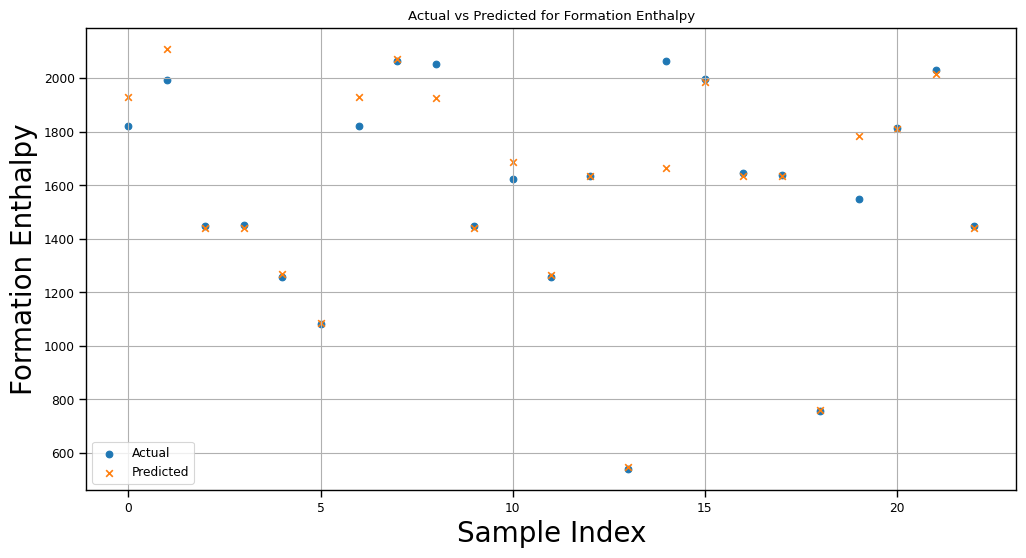

In [22]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test[:, 0], label='Actual', marker='o')
plt.scatter(range(len(y_pred)), y_pred[:, 0], label='Predicted', marker='x')
plt.title('Actual vs Predicted for Formation Enthalpy')
plt.xlabel('Sample Index')
plt.ylabel('Formation Enthalpy')
plt.legend()
plt.grid(True)
plt.show()

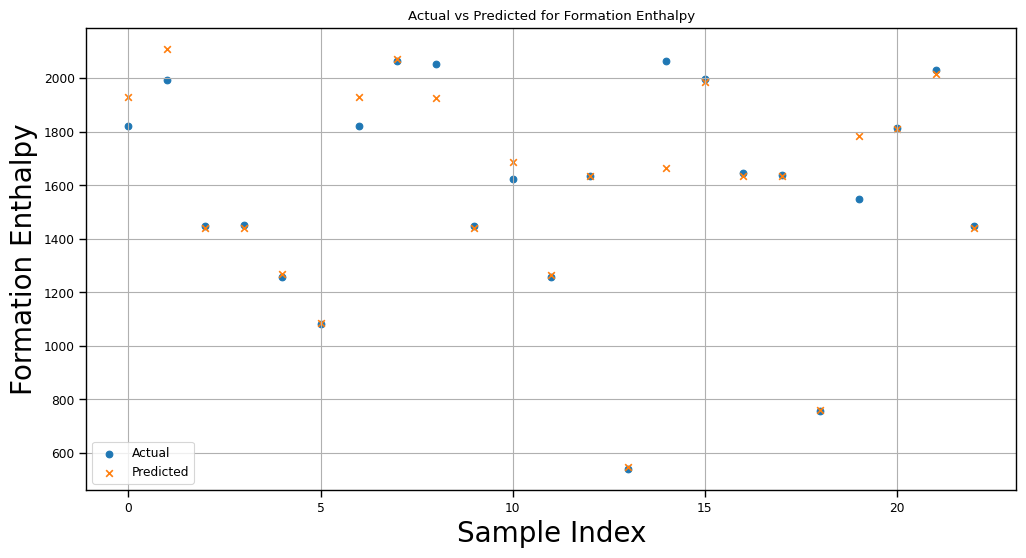

In [23]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test[:, 0], label='Actual', marker='o')
plt.scatter(range(len(y_pred)), y_pred[:, 0], label='Predicted', marker='x')
plt.title('Actual vs Predicted for Formation Enthalpy')
plt.xlabel('Sample Index')
plt.ylabel('Formation Enthalpy')
plt.legend()
plt.grid(True)
plt.show()

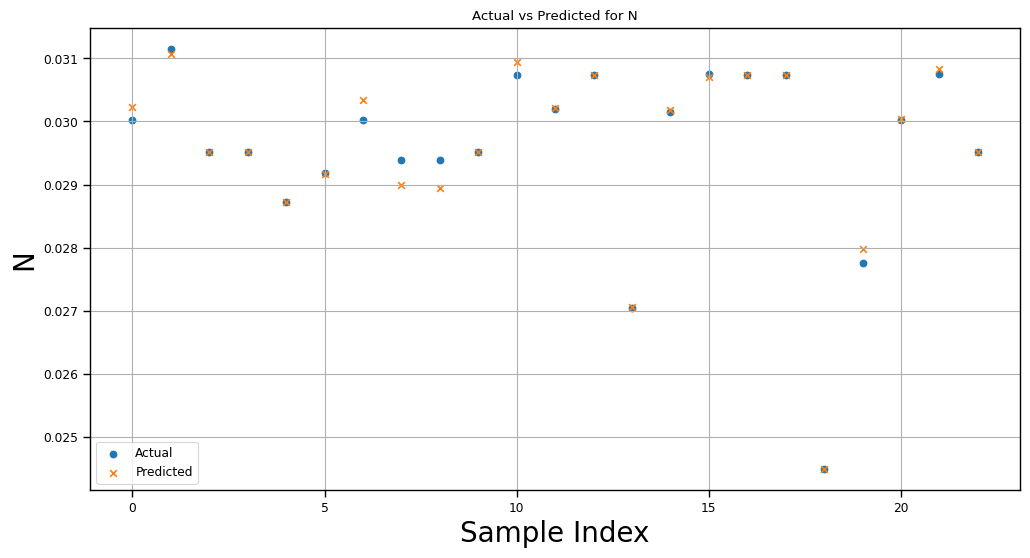

In [24]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test[:, 1], label='Actual', marker='o')
plt.scatter(range(len(y_pred)), y_pred[:, 1], label='Predicted', marker='x')
plt.title('Actual vs Predicted for N')
plt.xlabel('Sample Index')
plt.ylabel('N')
plt.legend()
plt.grid(True)
plt.show()

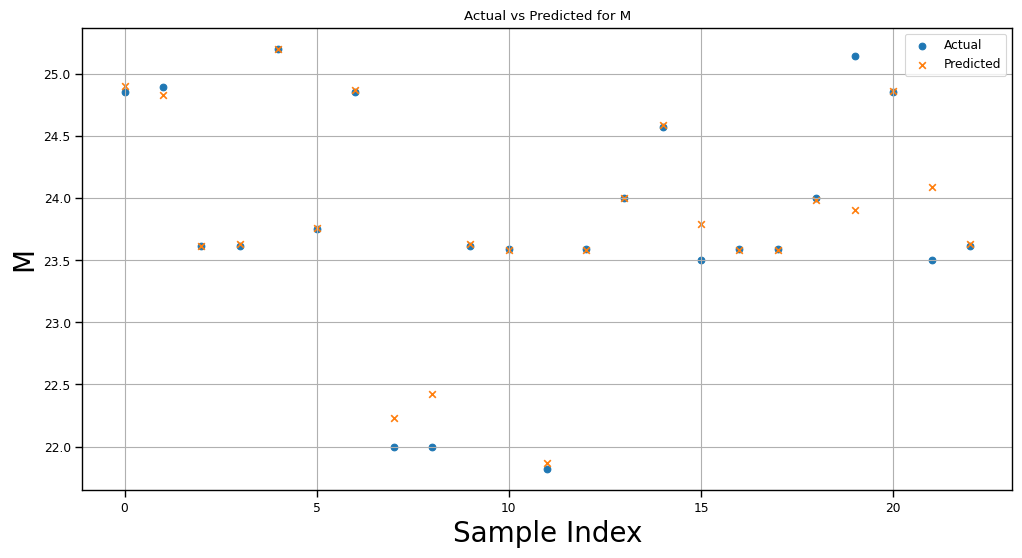

In [25]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test[:, 2], label='Actual', marker='o')
plt.scatter(range(len(y_pred)), y_pred[:, 2], label='Predicted', marker='x')
plt.title('Actual vs Predicted for M')
plt.xlabel('Sample Index')
plt.ylabel('M')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
y_test[:, 3]

array([10427.44, 10558.17, 10109.62, 10121.35, 10035.74,  9786.28,
       10434.57, 10324.38, 10296.54, 10108.34, 10236.08,  9827.68,
       10273.1 ,  9173.08, 10305.98, 10459.45, 10308.08, 10287.87,
        9158.68, 11168.79, 10411.13, 10550.8 , 10117.1 ])

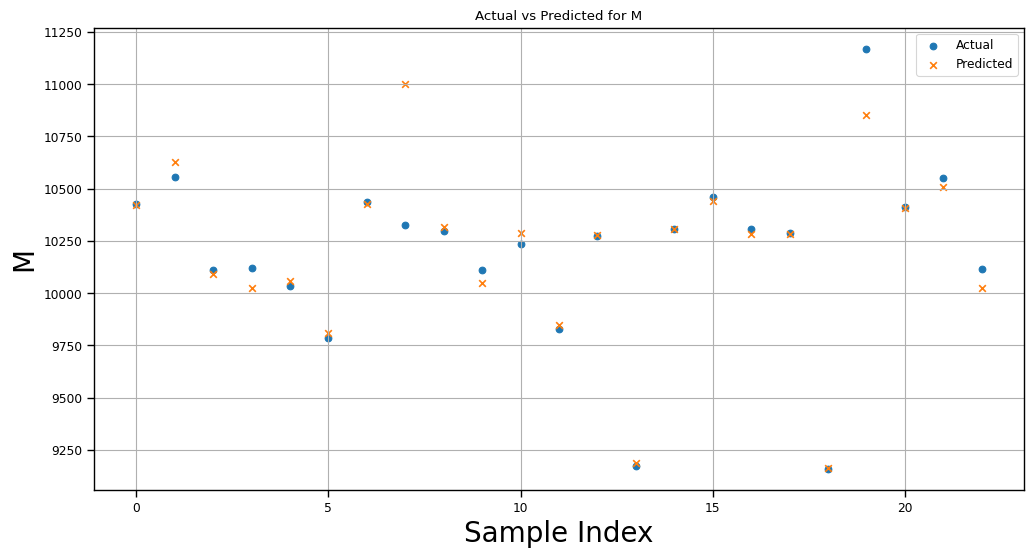

In [27]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test[:, 3], label='Actual', marker='o')
plt.scatter(range(len(y_pred)), y_pred[:, 3], label='Predicted', marker='x')
plt.title('Actual vs Predicted for M')
plt.xlabel('Sample Index')
plt.ylabel('M')
plt.legend()
plt.grid(True)
plt.show()

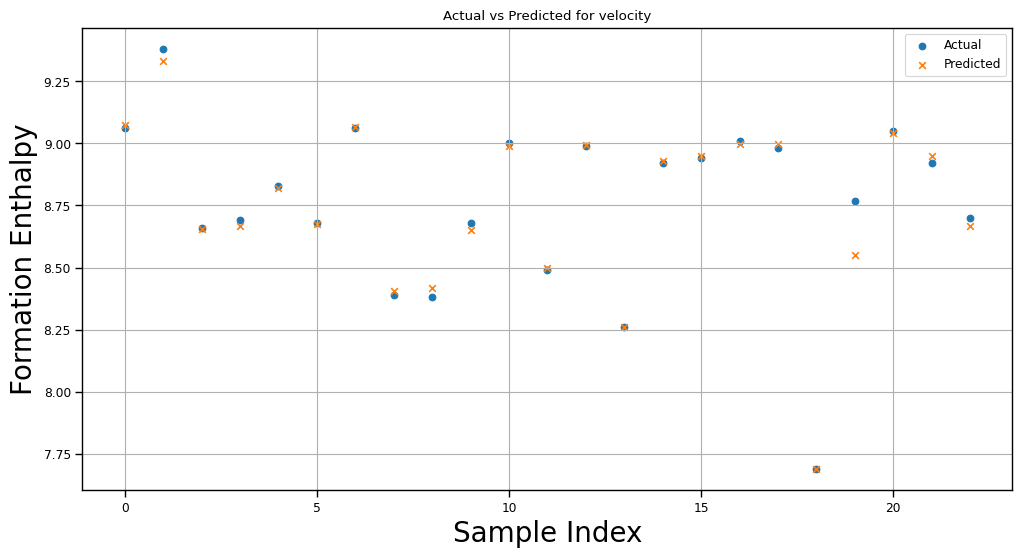

In [28]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test[:, 4], label='Actual', marker='o')
plt.scatter(range(len(y_pred)), y_pred[:, 4], label='Predicted', marker='x')
plt.title('Actual vs Predicted for velocity')
plt.xlabel('Sample Index')
plt.ylabel('Formation Enthalpy')
plt.legend()
plt.grid(True)
plt.show()

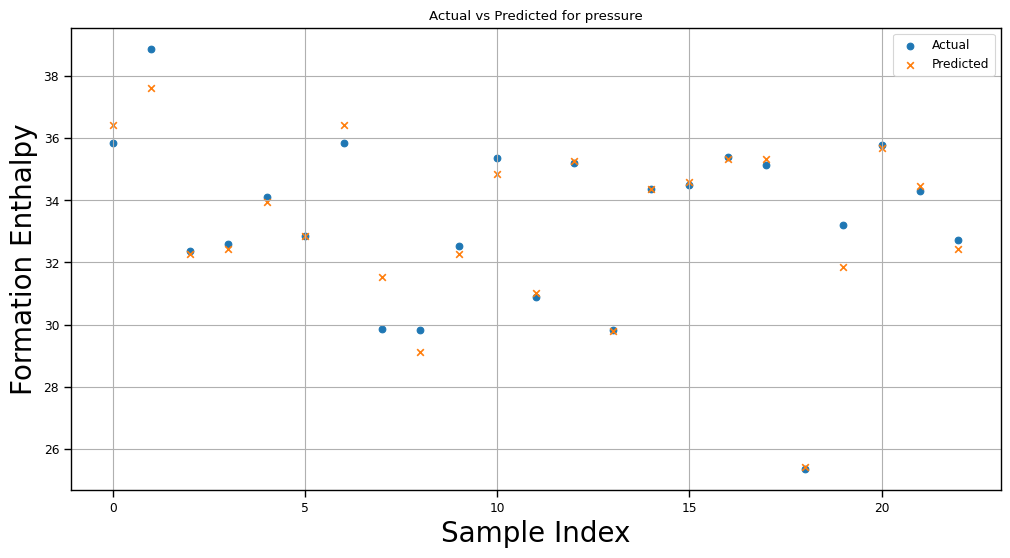

In [29]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test[:, 5], label='Actual', marker='o')
plt.scatter(range(len(y_pred)), y_pred[:, 5], label='Predicted', marker='x')
plt.title('Actual vs Predicted for pressure')
plt.xlabel('Sample Index')
plt.ylabel('Formation Enthalpy')
plt.legend()
plt.grid(True)
plt.show()

# Learning curve

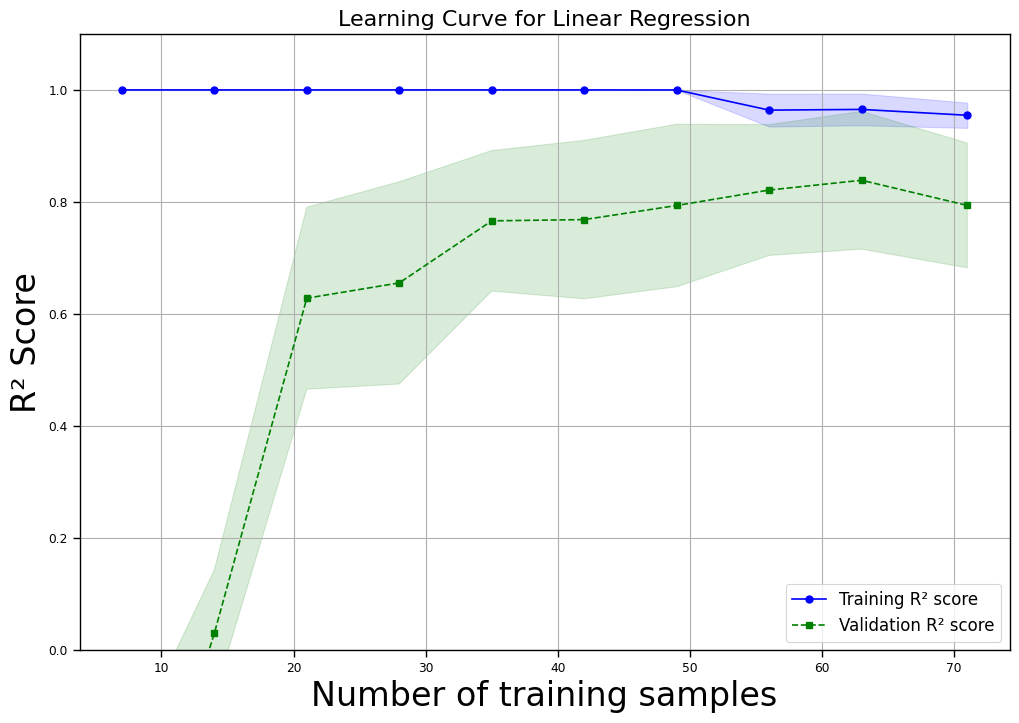

In [31]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=gbr,
    X=X_train_reduced,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 8))

plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training R² score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation R² score')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

plt.title('Learning Curve for Linear Regression', fontsize=16)
plt.xlabel('Number of training samples', fontsize=24)
plt.ylabel('R² Score', fontsize=24)
plt.grid()
plt.legend(loc='lower right', fontsize=12)
plt.ylim([0.0, 1.1])
plt.show()


# Testing on actual data

In [ ]:
test_df = pd.read_csv("test.csv")
test_df.head()

In [ ]:
test_input = test_df.values
test_input_reduced = pca.transform(test_input)
test_pred = lr.predict(test_input_reduced)
test_pred_df = pd.DataFrame(test_pred, columns=['Formation Enthalpy', 'N', 'M', 'HOT', 'velocity', 'pressure'])
test_pred_df.to_csv('test_predictions.csv', index=False)

In [59]:
print(df.columns[27:])  # target column names


Index(['Input Formation Enthalpy (kJ/mol)', 'N(mol/g)', 'M(g/mol)', 'HOT(J/g)',
       'veloci(km/s)', 'press(Gpa)'],
      dtype='object')
